In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("./sms_spam_collection/SMSSpamCollection",sep='\t',header=None,
    names=["label", "message"])

In [3]:
print("-------------------- HEAD --------------------")
print(df.head())
print("-------------------- DESCRIBE --------------------")
print(df.describe())
print("-------------------- INFO --------------------")
print(df.info())

-------------------- HEAD --------------------
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
-------------------- DESCRIBE --------------------
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30
-------------------- INFO --------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [4]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 label      0
message    0
dtype: int64


In [5]:
# Check for duplicates
print("Duplicate entries:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

Duplicate entries: 403


In [6]:
df.head()
df.describe()

,label,message
count,5169,5169
unique,2,5169
top,ham,Rofl. Its true to its name
freq,4516,1


In [7]:
#Preprocessing the Spam Dataset

In [8]:
import nltk

# Download the necessary NLTK data files
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

print("=== BEFORE ANY PREPROCESSING ===") 
print(df.head(5))

=== BEFORE ANY PREPROCESSING ===
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


[nltk_data] Downloading package punkt to /home/jaswanth/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/jaswanth/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/jaswanth/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
df["message"]=df["message"].str.lower()

In [10]:
df["message"].head()

0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
3    u dun say so early hor... u c already then say...
4    nah i don't think he goes to usf, he lives aro...
Name: message, dtype: object

In [11]:
import re

# Remove non-essential punctuation and numbers, keep useful symbols like $ and !
df["message"] = df["message"].apply(lambda x: re.sub(r"[^a-z\s$!]", "", x))
print("\n=== AFTER REMOVING PUNCTUATION & NUMBERS (except $ and !) ===")
print(df["message"].head(5))


=== AFTER REMOVING PUNCTUATION & NUMBERS (except $ and !) ===
0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in  a wkly comp to win fa cup final...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: message, dtype: object


In [12]:
#Tokenizing the text

In [13]:
from nltk.tokenize import word_tokenize

# Split each message into individual tokens
df["message"] = df["message"].apply(word_tokenize)
print("\n=== AFTER TOKENIZATION ===")
print(df["message"].head(5))


=== AFTER TOKENIZATION ===
0    [go, until, jurong, point, crazy, available, o...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, in, a, wkly, comp, to, win, fa, ...
3    [u, dun, say, so, early, hor, u, c, already, t...
4    [nah, i, dont, think, he, goes, to, usf, he, l...
Name: message, dtype: object


In [14]:
#Removing the stop words

In [15]:
from nltk.corpus import stopwords

# Define a set of English stop words and remove them from the tokens
stop_words = set(stopwords.words("english"))
print(stop_words)
df["message"] = df["message"].apply(lambda x: [word for word in x if word not in stop_words])
print("\n=== AFTER REMOVING STOP WORDS ===")
print(df["message"].head(5))

{"shan't", "she's", "they've", 'had', 'shouldn', 'shan', 'you', "isn't", 'not', "that'll", 'and', 'it', 'between', "she'll", 'wasn', 'mustn', "i'll", 'be', "couldn't", 'same', 'him', 'ourselves', 'being', 'hers', 'isn', 'theirs', 'how', 'in', "they'll", 'hadn', 'against', 'we', 'from', 'until', "mightn't", 'am', "i've", 'ours', 'his', 'there', 'now', 'd', 'he', "won't", 'while', 'these', 'mightn', 'at', 'should', 'during', 'them', 'with', 'their', 'been', 'further', "doesn't", 'its', 'after', "you'd", "she'd", 'into', 'o', 'out', 'were', 'couldn', "you've", "they're", 'or', 'doing', 'nor', 'themselves', 'other', 'himself', 'some', 'yourself', 'y', 'each', 'but', 'those', 'where', 'for', "he's", 'here', 'weren', 'me', 'about', 's', 'then', 'so', 'a', 'didn', 'wouldn', 'by', 'yours', 'yourselves', 'ain', 'down', 'doesn', 'don', 'the', 'this', "we're", 'that', 'through', 'i', 'very', 've', 're', 'haven', "you'll", "weren't", 'as', "haven't", 'again', 'just', "they'd", 'under', 'above', 'u

In [16]:
#stemming 

In [17]:
from nltk.stem import PorterStemmer

# Stem each token to reduce words to their base form
stemmer = PorterStemmer()
df["message"] = df["message"].apply(lambda x: [stemmer.stem(word) for word in x])
print("\n=== AFTER STEMMING ===")
print(df["message"].head(5))


=== AFTER STEMMING ===
0    [go, jurong, point, crazi, avail, bugi, n, gre...
1                         [ok, lar, joke, wif, u, oni]
2    [free, entri, wkli, comp, win, fa, cup, final,...
3        [u, dun, say, earli, hor, u, c, alreadi, say]
4    [nah, dont, think, goe, usf, live, around, tho...
Name: message, dtype: object


In [18]:
#Joining Tokens Back into a Single String [Preprocess-complete]

In [19]:
# Rejoin tokens into a single string for feature extraction
df["message"] = df["message"].apply(lambda x: " ".join(x))
print("\n=== AFTER JOINING TOKENS BACK INTO STRINGS ===")
print(df["message"].head(5))


=== AFTER JOINING TOKENS BACK INTO STRINGS ===
0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri wkli comp win fa cup final tkt st m...
3                  u dun say earli hor u c alreadi say
4            nah dont think goe usf live around though
Name: message, dtype: object


In [20]:
#Feature Extraction

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer with bigrams, min_df, and max_df to focus on relevant terms
vectorizer = CountVectorizer(min_df=1, max_df=0.9, ngram_range=(1, 2))

# Fit and transform the message column
X = vectorizer.fit_transform(df["message"])
print(X)
# Labels (target variable)
y = df["label"].apply(lambda x: 1 if x == "spam" else 0)  # Converting labels to 1 and 0

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 80181 stored elements and shape (5169, 37069)>
  Coords	Values
  (0, 11685)	1
  (0, 15918)	1
  (0, 24208)	1
  (0, 6180)	1
  (0, 1833)	1
  (0, 3594)	1
  (0, 12498)	1
  (0, 35945)	1
  (0, 16556)	1
  (0, 3589)	1
  (0, 4996)	1
  (0, 12237)	1
  (0, 950)	1
  (0, 34576)	1
  (0, 11796)	1
  (0, 15919)	1
  (0, 24211)	1
  (0, 6182)	1
  (0, 1835)	1
  (0, 3596)	1
  (0, 12560)	1
  (0, 35957)	1
  (0, 16557)	1
  (0, 3590)	1
  (0, 5002)	1
  :	:
  (5167, 3678)	1
  (5167, 8610)	1
  (5167, 11054)	1
  (5167, 12750)	1
  (5167, 15306)	1
  (5167, 21442)	1
  (5167, 186)	1
  (5167, 2901)	1
  (5167, 28676)	1
  (5167, 12753)	1
  (5167, 2902)	1
  (5167, 188)	1
  (5167, 17377)	1
  (5167, 14613)	1
  (5167, 15307)	1
  (5167, 3721)	1
  (5167, 8614)	1
  (5167, 34887)	1
  (5167, 11063)	1
  (5167, 33679)	1
  (5168, 20913)	1
  (5168, 32812)	1
  (5168, 26209)	1
  (5168, 26211)	1
  (5168, 32825)	1


In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Build the pipeline by combining vectorization and classification
pipeline = Pipeline([
    ("vectorizer", vectorizer),
    ("classifier", MultinomialNB())
])

In [24]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    "classifier__alpha": [0.01, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 1.0]
}

# Perform the grid search with 5-fold cross-validation and the F1-score as metric
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)

# Fit the grid search on the full dataset
grid_search.fit(df["message"], y)

# Extract the best model identified by the grid search
best_model = grid_search.best_estimator_
print("Best model parameters:", grid_search.best_params_)

Best model parameters: {'classifier__alpha': 0.25}


In [25]:
# Example SMS messages for evaluation
new_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Go to http://bit.ly/1234 to claim now.",
    "Hey, are we still meeting up for lunch today?",
    "Urgent! Your account has been compromised. Verify your details here: www.fakebank.com/verify",
    "Reminder: Your appointment is scheduled for tomorrow at 10am.",
    "FREE entry in a weekly competition to win an iPad. Just text WIN to 80085 now!",
]

In [26]:
import numpy as np
import re

# Preprocess function that mirrors the training-time preprocessing
def preprocess_message(message):
    message = message.lower()
    message = re.sub(r"[^a-z\s$!]", "", message)
    tokens = word_tokenize(message)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)

In [29]:
# Preprocess and vectorize messages
processed_messages = [preprocess_message(msg) for msg in new_messages]
print(processed_messages[0])

congratul ! youv $ walmart gift card go httpbitli claim


In [30]:
# Transform preprocessed messages into feature vectors
X_new = best_model.named_steps["vectorizer"].transform(processed_messages)

In [32]:
# Predict with the trained classifier
predictions = best_model.named_steps["classifier"].predict(X_new)
prediction_probabilities = best_model.named_steps["classifier"].predict_proba(X_new)

In [33]:
# Display predictions and probabilities for each evaluated message
for i, msg in enumerate(new_messages):
    prediction = "Spam" if predictions[i] == 1 else "Not-Spam"
    spam_probability = prediction_probabilities[i][1]  # Probability of being spam
    ham_probability = prediction_probabilities[i][0]   # Probability of being not spam
    
    print(f"Message: {msg}")
    print(f"Prediction: {prediction}")
    print(f"Spam Probability: {spam_probability:.2f}")
    print(f"Not-Spam Probability: {ham_probability:.2f}")
    print("-" * 50)

Message: Congratulations! You've won a $1000 Walmart gift card. Go to http://bit.ly/1234 to claim now.
Prediction: Spam
Spam Probability: 1.00
Not-Spam Probability: 0.00
--------------------------------------------------
Message: Hey, are we still meeting up for lunch today?
Prediction: Not-Spam
Spam Probability: 0.00
Not-Spam Probability: 1.00
--------------------------------------------------
Message: Urgent! Your account has been compromised. Verify your details here: www.fakebank.com/verify
Prediction: Spam
Spam Probability: 0.96
Not-Spam Probability: 0.04
--------------------------------------------------
Message: Reminder: Your appointment is scheduled for tomorrow at 10am.
Prediction: Not-Spam
Spam Probability: 0.00
Not-Spam Probability: 1.00
--------------------------------------------------
Message: FREE entry in a weekly competition to win an iPad. Just text WIN to 80085 now!
Prediction: Spam
Spam Probability: 1.00
Not-Spam Probability: 0.00
----------------------------------

In [34]:
import joblib

# Save the trained model to a file for future use
model_filename = 'spam_detection_model.joblib'
joblib.dump(best_model, model_filename)

print(f"Model saved to {model_filename}")

Model saved to spam_detection_model.joblib


In [36]:
#To load a model

In [37]:
# Load the saved model
#loaded_model = joblib.load(model_filename)

# Preprocess new messages before prediction
#new_data_processed = [preprocess_message(msg) for msg in new_messages]

# Make predictions on the preprocessed data
#predictions = loaded_model.predict(new_data_processed)

=================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

     Ham (0)     0.9845    0.9878    0.9862       903
    Spam (1)     0.9141    0.8931    0.9035       131

    accuracy                         0.9758      1034
   macro avg     0.9493    0.9405    0.9448      1034
weighted avg     0.9756    0.9758    0.9757      1034



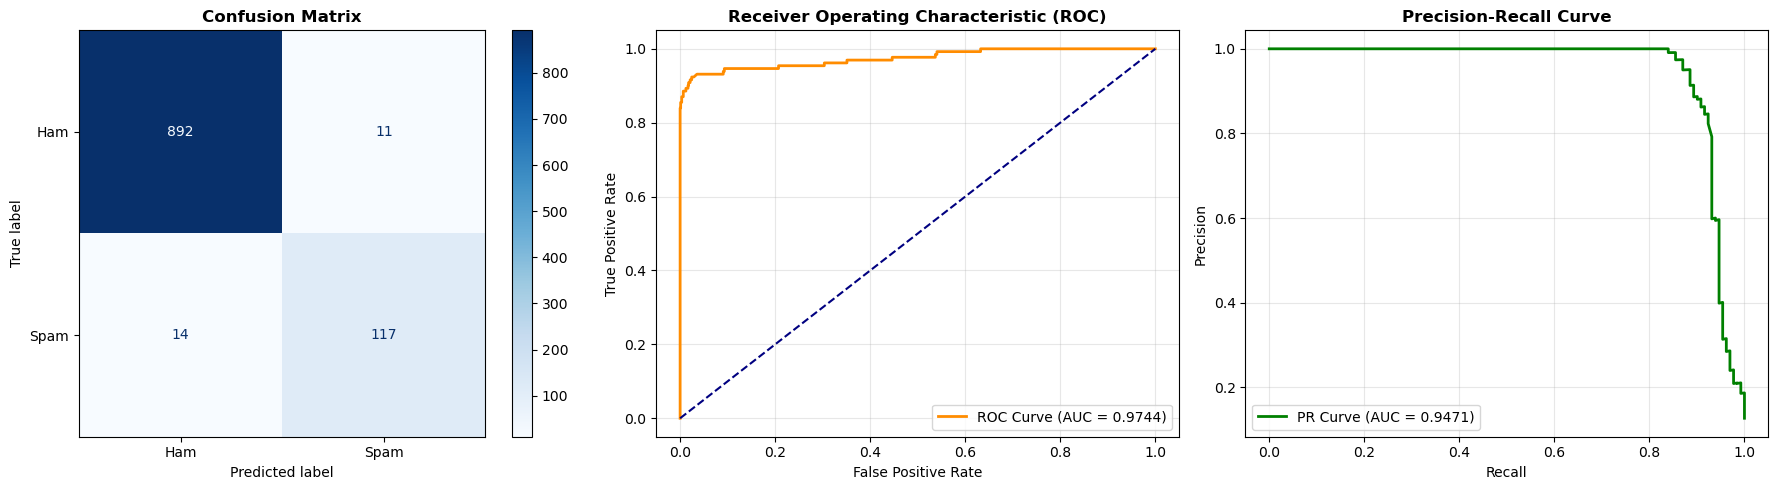

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

# 1. Split data into training and holdout test sets (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], y, test_size=0.20, random_state=42, stratify=y
)

# 2. Re-fit best model on training set and generate predictions for test set
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 3. Print Textual Metrics Summary
print("=================== CLASSIFICATION REPORT ===================")
print(
    classification_report(
        y_test, y_pred, target_names=["Ham (0)", "Spam (1)"], digits=4
    )
)

# 4. Generate Diagnostic Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Ham", "Spam"]
)
disp.plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("Confusion Matrix", fontsize=12, fontweight="bold")

# --- Plot 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
axes[1].plot(
    fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})"
)
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(
    "Receiver Operating Characteristic (ROC)", fontsize=12, fontweight="bold"
)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
axes[2].plot(
    recall,
    precision,
    color="green",
    lw=2,
    label=f"PR Curve (AUC = {pr_auc:.4f})",
)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title(
    "Precision-Recall Curve", fontsize=12, fontweight="bold"
)
axes[2].legend(loc="lower left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()